# Exploração inicial — Instrumentos Contratuais com Alterações e Medições (TCE-ES)

Dataset: `[TCEES] Contratações - Controle Externo`
Fonte: https://dados.es.gov.br/dataset/tcees-contratacoes

Objetivo desta etapa: entender volume, qualidade e distribuição dos dados
antes de desenhar o schema relacional (MySQL) e o indicador de risco.

In [1]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

CAMINHO_CSV = Path("..") / "data" / "raw" / "instrumentos_contratuais_alteracoes.csv"

# Encoding e separador confirmados na etapa de download
ENCODING = "latin-1"
SEP = ";"

assert CAMINHO_CSV.exists(), f"Arquivo não encontrado em {CAMINHO_CSV.resolve()}"

## 1. Contar linhas totais (sem carregar tudo na memória)

O arquivo tem ~1.1 GB. Antes de carregar, é bom saber quantas linhas existem
de fato, lendo em blocos (`chunksize`).

In [2]:
total_linhas = 0
for chunk in pd.read_csv(CAMINHO_CSV, sep=SEP, encoding=ENCODING, usecols=[0], chunksize=200_000):
    total_linhas += len(chunk)

print(f"Total de linhas no CSV: {total_linhas:,}")

Total de linhas no CSV: 912,881


## 2. Carregar apenas as colunas relevantes para a análise de sobrecusto

Carregar as 73 colunas de uma vez consome muita memória à toa. Aqui
selecionamos só o que interessa para as primeiras perguntas:
- Identificação do contrato/instrumento
- Valores (inicial, atual, aditivo, medição)
- Fornecedor e órgão
- Datas principais

In [3]:
COLUNAS_RELEVANTES = [
    "IdentificacaoContratacao",
    "ChaveInstrumento",
    "ModalidadeLicitacao",
    "SituacaoContratacao",
    "ValorEstimado",
    "ValorTotalContratacao",
    "ValorTotalContratacaoInstrumento",   # valor inicial do contrato
    "ValorAtualContratacaoInstrumento",   # valor atual (após aditivos)
    "DataAssinaturaInstrumentoContratacao",
    "InicioVigenciaContrato",
    "FimVigenciaContrato",
    "SituacaoInstrumento",
    "TipoInstrumento",
    "RegimeExecucao",
    "NumeroTermoContratualAlteracao",
    "AnoTermoContratualAlteracao",
    "TipoTermoContratualAlteracao",
    "DataAssinaturaTermoAlteracaoContratual",
    "JustificativaAlteracao",
    "ValorTotalContratacaoAlteracao",
    "NumeroIdentificacaoContratado",
    "NomeContratado",
    "CodigoUnidadeGestoraReferencia",
    "NomeUnidadeGestoraReferencia",
]

df = pd.read_csv(
    CAMINHO_CSV,
    sep=SEP,
    encoding=ENCODING,
    usecols=COLUNAS_RELEVANTES,
    decimal=",",       # números em CSVs BR costumam usar vírgula decimal
    low_memory=False,
)

print(df.shape)
df.head()

(912881, 24)


,IdentificacaoContratacao,SituacaoContratacao,ModalidadeLicitacao,ValorEstimado,ValorTotalContratacao,CodigoUnidadeGestoraReferencia,NomeUnidadeGestoraReferencia,DataAssinaturaInstrumentoContratacao,NumeroIdentificacaoContratado,NomeContratado,InicioVigenciaContrato,FimVigenciaContrato,SituacaoInstrumento,TipoInstrumento,RegimeExecucao,ValorTotalContratacaoInstrumento,ValorAtualContratacaoInstrumento,NumeroTermoContratualAlteracao,AnoTermoContratualAlteracao,TipoTermoContratualAlteracao,DataAssinaturaTermoAlteracaoContratual,JustificativaAlteracao,ValorTotalContratacaoAlteracao,ChaveInstrumento
0,2020.037E0700001.02.0025,Não há dados enviados,Pregão Presencial,NaN,NaN,037E0500001,Fundo Municipal de Saúde de Iúna,2023-11-28,24110384000163,FERNANDO CEZAR ARAUJO,2023-11-28,2024-09-21,Instrumento Contratual Finalizado,Contrato,Execução direta,32000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,037E0500001-2020.037E0700001.02.0025-000041-20...
1,2020.037E0700001.02.0025,Não há dados enviados,Pregão Presencial,NaN,NaN,037E0500001,Fundo Municipal de Saúde de Iúna,2025-03-06,24110384000163,FERNANDO CEZAR ARAUJO,2025-03-06,2026-03-06,Instrumento Contratual Finalizado,Contrato,Execução direta,23000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,037E0500001-2020.037E0700001.02.0025-000041-20...
2,2020.037E0700001.02.0025,Não há dados enviados,Pregão Presencial,NaN,NaN,037E0500001,Fundo Municipal de Saúde de Iúna,2026-04-29,24110384000163,FERNANDO CEZAR ARAUJO,2026-04-29,2026-09-20,Instrumento Contratual em Execução,Contrato,Execução direta,105000.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,037E0500001-2020.037E0700001.02.0025-000041-20...
3,2021.017E0500002.02.0044,Ata de Registro de Preços finalizada,Concorrência,NaN,9901027.96,017E0500002,Fundo Municipal de Saúde de Cariacica,2022-10-13,00471823000103,HIMALAIA REFRIGERACAO E CONSERVACAO EIRELI,2022-10-13,2023-10-12,Instrumento Contratual em Execução,Contrato,Execução indireta: Empreitada por preço unitário,6829855.97,35358336.77,NaN,NaN,NaN,NaN,NaN,NaN,017E0500002-2021.017E0500002.02.0044-000000000...
4,2021.018E0700001.01.0103,Licitação apta a contratar,Pregão Presencial,NaN,236400.12,018E0700001,Prefeitura Municipal de Castelo,2023-08-07,31730898000187,ECO-TECH SOLUÇÕES AMBIENTAIS LTDA,2023-08-18,2024-08-17,Instrumento Contratual em Execução,Contrato,Execução indireta: Empreitada por preço unitário,234000.00,704961.98,NaN,NaN,NaN,NaN,NaN,NaN,018E0700001-2021.018E0700001.01.0103-000026-20...


## 3. Qualidade dos dados: valores nulos por coluna

In [4]:
nulos = df.isna().sum().sort_values(ascending=False)
percentual_nulos = (nulos / len(df) * 100).round(1)
pd.DataFrame({"nulos": nulos, "percentual": percentual_nulos})

,nulos,percentual
ValorTotalContratacaoAlteracao,892101,97.7
JustificativaAlteracao,868178,95.1
NumeroTermoContratualAlteracao,868177,95.1
AnoTermoContratualAlteracao,868177,95.1
DataAssinaturaTermoAlteracaoContratual,868177,95.1
TipoTermoContratualAlteracao,868177,95.1
ValorAtualContratacaoInstrumento,595355,65.2
ValorEstimado,476965,52.2
ModalidadeLicitacao,364849,40.0
RegimeExecucao,337069,36.9


## 4. Checar se os valores numéricos vieram corretamente convertidos

Se `decimal=","` estiver errado (ou o arquivo já usar ponto), essas colunas
aparecerão como `object` (texto) em vez de `float64`.

In [5]:
colunas_valor = [
    "ValorEstimado",
    "ValorTotalContratacao",
    "ValorTotalContratacaoInstrumento",
    "ValorAtualContratacaoInstrumento",
    "ValorTotalContratacaoAlteracao",
]
df[colunas_valor].dtypes

ValorEstimado                       float64
ValorTotalContratacao               float64
ValorTotalContratacaoInstrumento    float64
ValorAtualContratacaoInstrumento    float64
ValorTotalContratacaoAlteracao      float64
dtype: object

## 5. Quantos contratos têm pelo menos um termo aditivo?

Cada linha do CSV é, na prática, uma combinação de (instrumento x aditivo x
medição). Um mesmo contrato (`ChaveInstrumento`) aparece várias vezes se
tiver vários aditivos ou medições. Por isso, para contar contratos únicos,
usamos `ChaveInstrumento`, não o total de linhas.

In [6]:
total_contratos = df["ChaveInstrumento"].nunique()
print(f"Contratos (instrumentos) únicos: {total_contratos:,}")

contratos_com_aditivo = df.loc[
    df["NumeroTermoContratualAlteracao"].notna(), "ChaveInstrumento"
].nunique()
print(f"Contratos com pelo menos 1 termo aditivo: {contratos_com_aditivo:,}")
print(f"Percentual com aditivo: {contratos_com_aditivo / total_contratos * 100:.1f}%")

Contratos (instrumentos) únicos: 196,362
Contratos com pelo menos 1 termo aditivo: 20,934
Percentual com aditivo: 10.7%


## 5.1 Diagnóstico: `ValorTotalContratacaoInstrumento` e `ValorAtualContratacaoInstrumento` são constantes por contrato?

O indicador de sobrecusto abaixo usa `drop_duplicates(subset="ChaveInstrumento")`,
assumindo que essas duas colunas têm **um único valor por contrato** (o CSV
tem 1 linha por combinação instrumento x aditivo x medição, então o valor
"atual" deveria se repetir igual em todas as linhas do mesmo instrumento,
só mudando conforme novos aditivos são registrados — mas nunca dentro do
mesmo aditivo/medição).

Se isso for falso, `drop_duplicates()` pega a *primeira* linha que aparecer
para cada `ChaveInstrumento`, que pode não ser a mais recente/correta — daí
os percentuais absurdos (ex: 22 milhões %).

In [7]:
variacao_valores = df.groupby("ChaveInstrumento").agg(
    qtd_linhas=("ChaveInstrumento", "size"),
    valores_distintos_total=("ValorTotalContratacaoInstrumento", "nunique"),
    valores_distintos_atual=("ValorAtualContratacaoInstrumento", "nunique"),
)

instrumentos_total_varia = (variacao_valores["valores_distintos_total"] > 1).sum()
instrumentos_atual_varia = (variacao_valores["valores_distintos_atual"] > 1).sum()

print(f"Instrumentos com ValorTotalContratacaoInstrumento variando: {instrumentos_total_varia:,} "
      f"de {len(variacao_valores):,} ({instrumentos_total_varia / len(variacao_valores) * 100:.1f}%)")
print(f"Instrumentos com ValorAtualContratacaoInstrumento variando: {instrumentos_atual_varia:,} "
      f"de {len(variacao_valores):,} ({instrumentos_atual_varia / len(variacao_valores) * 100:.1f}%)")

# Exemplo concreto: pega o instrumento com mais valores distintos de ValorAtualContratacaoInstrumento
if instrumentos_atual_varia > 0:
    chave_exemplo = variacao_valores["valores_distintos_atual"].idxmax()
    print(f"\nExemplo — ChaveInstrumento={chave_exemplo!r} "
          f"({variacao_valores.loc[chave_exemplo, 'valores_distintos_atual']} valores distintos de ValorAtual):")
    display(
        df.loc[
            df["ChaveInstrumento"] == chave_exemplo,
            [
                "ChaveInstrumento",
                "NumeroTermoContratualAlteracao",
                "TipoTermoContratualAlteracao",
                "ValorTotalContratacaoInstrumento",
                "ValorAtualContratacaoInstrumento",
                "ValorTotalContratacaoAlteracao",
            ],
        ]
    )

variacao_valores.sort_values("valores_distintos_atual", ascending=False).head(10)

Instrumentos com ValorTotalContratacaoInstrumento variando: 0 de 196,362 (0.0%)
Instrumentos com ValorAtualContratacaoInstrumento variando: 0 de 196,362 (0.0%)


,qtd_linhas,valores_distintos_total,valores_distintos_atual
ChaveInstrumento,,,
032E0700001-2024.032E0700001.02.0001-000002-2024-000030-ARP-2024,19,1,1
016E0700001-2024.016E0700001.01.0025-000011-2024-000278-2024,4,1,1
058E0600005-2023.058E0600005.09.0157-000543-2023,35,1,1
001E0500001-2022.001E0500001.01.0002-000002-2022-000014-2022,30,1,1
018E0700001-2025.018E0700001.02.0003-000004-2025-113249-2025,3,1,1
001E0500001-2022.001E0500001.01.0004-000028-2022-000013-2022,11,1,1
032E0700001-2024.032E0700001.02.0001-000002-2024-000032-ARP-2024,2,1,1
058E0600005-2023.058E0600005.09.0158-000542-2023,34,1,1
001E0500001-2022.001E0500001.09.0004-000009-2022,34,1,1


## 6. Indicador de sobrecusto por contrato

Agregamos por `ChaveInstrumento` (1 linha por contrato) e calculamos o
percentual de variação entre o valor inicial e o valor atual.

In [8]:
contratos = (
    df.drop_duplicates(subset="ChaveInstrumento")
    .loc[:, [
        "ChaveInstrumento",
        "NomeContratado",
        "NomeUnidadeGestoraReferencia",
        "ModalidadeLicitacao",
        "ValorTotalContratacaoInstrumento",
        "ValorAtualContratacaoInstrumento",
    ]]
    .dropna(subset=["ValorTotalContratacaoInstrumento", "ValorAtualContratacaoInstrumento"])
)

# Evita divisão por zero
contratos = contratos[contratos["ValorTotalContratacaoInstrumento"] > 0]

contratos["percentual_sobrecusto"] = (
    (contratos["ValorAtualContratacaoInstrumento"] - contratos["ValorTotalContratacaoInstrumento"])
    / contratos["ValorTotalContratacaoInstrumento"]
    * 100
)

print(contratos["percentual_sobrecusto"].describe())
contratos.sort_values("percentual_sobrecusto", ascending=False).head(15)

count    1.250700e+04
mean     1.941296e+03
std      2.031279e+05
min     -1.000000e+02
25%      0.000000e+00
50%      1.000000e+02
75%      2.000000e+02
max      2.271657e+07
Name: percentual_sobrecusto, dtype: float64


,ChaveInstrumento,NomeContratado,NomeUnidadeGestoraReferencia,ModalidadeLicitacao,ValorTotalContratacaoInstrumento,ValorAtualContratacaoInstrumento,percentual_sobrecusto
123007,500J1200001-2024.500J1200001.01.0028-90068-202...,RC CARD SOLUCOES EM PAGAMENTOS LTDA,Tribunal de Justiça do Estado do Espírito Santo,Pregão Eletrônico,6.00,1363000.00,2.271657e+07
67076,058E0700001-2023.058E0700001.02.0001-000057-20...,MAFF EQUIPAMENTOS E PRODUCOES LTDA ME,Prefeitura Municipal de Presidente Kennedy,Pregão Eletrônico,4600.00,5267995.00,1.144216e+05
142874,053E0700001-2024.500E0500019.02.0417-0CGDN-202...,ABC FARMACEUTICO LTDA,Prefeitura Municipal de Pancas,Pregão Eletrônico,9.36,1413.36,1.500000e+04
190839,501C2600012-2025.501C2600012.02.0002-000004-20...,VITORIA PRIME RENTAL CAR - LOCACAO E COMERCIO ...,Consórcio Público da Região Norte do Espírito ...,Pregão Eletrônico,444600.00,55280400.00,1.233374e+04
150415,500L1100001-2024.500L1100001.09.0010-000030-2024,EXODO SERVICE LTDA,Assembleia Legislativa do Estado do Espírito S...,NaN,43083.72,5096986.65,1.173042e+04
14885,056E0700001-2022.056E0700001.01.0012-000025-20...,VIAÇÃO ALVORADA LTDA,Prefeitura Municipal de Piúma,Pregão Eletrônico,307200.00,33793654.80,1.090054e+04
98483,500E1600004-2023.500E1600004.12.0023-460000061...,ENGETRON ENGENHARIA ELETRONICA IND E COM LTDA,Banco do Estado do Espírito Santo S/A,NaN,7253.45,470305.04,6.383881e+03
150950,064E0700001-2024.501C2600002.02.0001-000004-20...,SUL AMBIENTAL SERVICOS DE MEIO AMBIENTE LTDA,Prefeitura Municipal de São Domingos do Norte,Pregão Eletrônico,7760.00,436500.00,5.525000e+03
11699,052E0500002-2022.052E0700001.01.0029-000021-20...,LINK CARD ADMINISTRADORA DE BENEFICIOS EIRELI,Fundo Municipal de Assistência Social de Nova ...,Pregão Eletrônico,390000.00,15436000.00,3.857949e+03
9270,028E0500001-2022.028E0700001.01.0071-183-2022-...,PORTO SEGURO COMPANHIA DE SEGUROS GERAIS,Fundo Municipal de Assistência Social de Guara...,Pregão Eletrônico,35900.00,1151219.81,3.106740e+03


## 7. Distribuição visual do sobrecusto

Ajuda a decidir os limiares (thresholds) do indicador de risco depois.

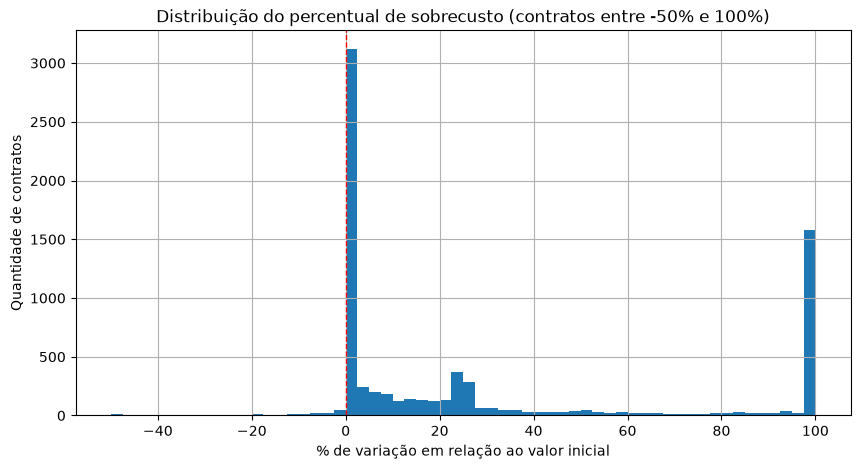

In [9]:
import matplotlib.pyplot as plt

# Recorte para remover outliers extremos na visualização (não no dado em si)
amostra = contratos[contratos["percentual_sobrecusto"].between(-50, 100)]

amostra["percentual_sobrecusto"].hist(bins=60, figsize=(10, 5))
plt.title("Distribuição do percentual de sobrecusto (contratos entre -50% e 100%)")
plt.xlabel("% de variação em relação ao valor inicial")
plt.ylabel("Quantidade de contratos")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.show()

## 8. Ranking de fornecedores por frequência e magnitude de sobrecusto

Primeira aproximação do indicador de risco por fornecedor — o objetivo
específico #3 do projeto ("Desenvolver um indicador de risco preditivo
com base no histórico financeiro dos contratos e fornecedores").

In [10]:
ranking_fornecedores = (
    contratos.groupby("NomeContratado")
    .agg(
        qtd_contratos=("ChaveInstrumento", "nunique"),
        sobrecusto_medio=("percentual_sobrecusto", "mean"),
        sobrecusto_maximo=("percentual_sobrecusto", "max"),
    )
    .query("qtd_contratos >= 3")  # só fornecedores com histórico mínimo
    .sort_values("sobrecusto_medio", ascending=False)
)

ranking_fornecedores.head(20)

,qtd_contratos,sobrecusto_medio,sobrecusto_maximo
NomeContratado,,,
RC CARD SOLUCOES EM PAGAMENTOS LTDA,5,4.543432e+06,2.271657e+07
ABC FARMACEUTICO LTDA,4,3.775000e+03,1.500000e+04
EXODO SERVICE LTDA,4,2.962090e+03,1.173042e+04
DM EVENTOS LTDA,3,1.027478e+03,2.183023e+03
LAGOA AZUL TRANSPORTES LTDA,3,7.629427e+02,1.280000e+03
"AS COMERCIO, SERVIÇOS E COMUNICAÇÃO LTDA",5,6.880832e+02,2.533509e+03
T M A SOLUCOES TECNOLOGICAS LTDA,8,5.242510e+02,2.817701e+03
VIACAO HELLEN LTDA-ME,4,4.708292e+02,9.437614e+02
SIMPRESS COMERCIO LOCACAO E SERVICOS LTDA,5,4.577678e+02,2.284322e+03


## 9. Salvar base tratada (para o protótipo em Streamlit)

Exporta o `contratos` (1 linha por `ChaveInstrumento`, já com
`percentual_sobrecusto` calculado) para um CSV em `data/processed/`, que
servirá de fonte de dados para as primeiras telas do app.

Por ora não aplicamos nenhum piso/filtro sobre os valores absurdos
(ex: 22 milhões %) — a ideia desta etapa é avaliar a base como está e
montar as primeiras análises; o tratamento desses casos fica para depois.

In [11]:
PASTA_PROCESSED = Path("..") / "data" / "processed"
PASTA_PROCESSED.mkdir(parents=True, exist_ok=True)

CAMINHO_SAIDA = PASTA_PROCESSED / "contratos_tratados.csv"
contratos.to_csv(CAMINHO_SAIDA, index=False, encoding="utf-8")

print(f"Base tratada salva em: {CAMINHO_SAIDA.resolve()}")
print(f"Linhas: {len(contratos):,} | Colunas: {contratos.shape[1]}")

Base tratada salva em: C:\Users\Leonardo Matias\Downloads\TCC\prototipo\data\processed\contratos_tratados.csv
Linhas: 12,507 | Colunas: 7


## Próximos passos

1. Validar com o grupo se `ValorTotalContratacaoInstrumento` /
   `ValorAtualContratacaoInstrumento` são de fato os campos corretos
   para "valor inicial" e "valor final" (checar a documentação/dicionário
   de dados do dataset, se disponível no portal).
2. Decidir se o indicador de risco vai considerar só sobrecusto financeiro
   ou também atraso de prazo (`FimVigenciaContrato` vs. execução real).
3. Baixar e cruzar os datasets complementares: `Instrumentos contratuais`
   (dados cadastrais) e `Contratações` (dados da licitação em si).
4. Desenhar o schema relacional (Contratação → Instrumento → Aditivo →
   Medição → Fornecedor → Unidade Gestora) e escrever o script de carga
   para o MySQL.